# Chapter 13: Sampling

Source span: *Fundamentals of Computer Graphics*, printed pages 335-356, physical PDF pages 352-373.

## Chapter Goal

Sampling is the bridge between a geometric domain and a numerical estimator. By the end of this notebook, a sample is not just a random point: it is a point drawn with respect to a named measure, a known density, a transform from canonical uniform numbers, and a checkable variance or coverage consequence.

The chapter's recurring question is: **when a graphics algorithm asks for fair samples on a line space, disk, sphere, or hemisphere, what measure is being preserved and how can we tell?** We answer it with direct constructions, generated diagrams, numerical diagnostics, and final sanity checks.


## Translation guide

| Book concept | Computational object used here | Checkable invariant |
| --- | --- | --- |
| Measure on a set | A nonnegative weight integrated over area, angle, length, or solid angle | Empty/zero-dimensional sets contribute zero; weighted integrals normalize as expected |
| Natural line measure | Normal coordinates `(theta, r)` for lines hitting the unit square | The sampled region has area 4 and each sampled line clips the square |
| Probability density function | A callable `p(x)` or `p(omega)` plus a sampler | `p >= 0`, integral is 1, empirical CDF matches the target |
| Inverse CDF | A monotone warp from canonical `u in [0, 1)` | Applying the CDF to warped samples returns uniform numbers |
| Rejection sampling | Propose from a simple box/cube and keep accepted points | Acceptance ratio matches area or volume ratios |
| Stratification and quasi-random coverage | One sample per cell or a low-discrepancy sequence | Grid occupancy, discrepancy, and estimator RMSE improve over iid random points |
| Disk, sphere, hemisphere sampling | Explicit warps into polar coordinates, solid angle, and cosine/Phong densities | Radii, vector norms, `z` marginals, and estimator weights match theory |

## Visual storyboard

| Sequence | Artifact | Representation and library | Inspection target |
| --- | --- | --- | --- |
| Measures and line spaces | `measure-weighted-area-and-line-space.png` | Matplotlib heatmap, normal-coordinate region, clipped square lines | Weighting changes the measure, while normal line coordinates give a rectangular-area style measure |
| Inverse CDF and disk warp | `inverse-cdf-disk-warp.png` | Matplotlib CDF/pdf, histogram, and disk scatter plots | A square-to-domain warp must preserve area, not radius |
| Rejection and Metropolis | `rejection-metropolis-diagnostics.png` | Matplotlib acceptance and chain diagnostics | Rejection is simple but wastes and destroys stratification; Metropolis creates correlated samples |
| Variance and coverage | `variance-stratification-coverage.png` plus CSV tables | Matplotlib log RMSE and point patterns, SciPy Sobol sequence | Importance shape matters, but stratification can dominate variance and coverage |
| Sphere and hemisphere directions | `sphere-hemisphere-direction-sampling.html` and `sphere-hemisphere-direction-marginals.png` | Plotly 3D point clouds plus Matplotlib marginal histograms | Uniform solid angle, uniform hemisphere, cosine hemisphere, and Phong-like hemispheres have different `z` distributions |
| Applied lab | `hemisphere-estimator-lab.csv` | Repeated estimators for `int_H cos(theta) d omega = pi` | A density proportional to the integrand can collapse variance |


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

CHAPTER = 13
TOPIC = "chapter-13"
PRINTED_PAGES = "335-356"
PDF_PAGES = "352-373"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for directory in (FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: Fundamentals-of-Computer-Graphics
Artifacts: artifacts\chapter-13


In [2]:
import math

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import integrate
from scipy.spatial.distance import pdist
from scipy.stats import qmc
import sympy as sp
from IPython.display import display

from utils.artifacts import (
    assert_artifacts,
    book_relative,
    display_artifact,
    save_json,
    save_matplotlib,
    save_plotly_html,
    save_table_csv,
)
from utils.notebook_checks import assert_nonblank_image

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

RNG = np.random.default_rng(13013)
ARTIFACTS = []
PNG_ARTIFACTS = []
HTML_ARTIFACTS = []
CHECK_ARTIFACTS = []
TABLE_ARTIFACTS = []


def record_artifact(path, kind):
    path = Path(path)
    ARTIFACTS.append(path)
    if kind == "png":
        PNG_ARTIFACTS.append(path)
    elif kind == "html":
        HTML_ARTIFACTS.append(path)
    elif kind == "check":
        CHECK_ARTIFACTS.append(path)
    elif kind == "table":
        TABLE_ARTIFACTS.append(path)
    return path


def save_check(data, filename):
    return record_artifact(save_json(data, TOPIC, filename), "check")


def unit_disk_inverse(u, v, radius=1.0):
    phi = 2.0 * np.pi * u
    r = radius * np.sqrt(v)
    return np.column_stack((r * np.cos(phi), r * np.sin(phi))), r, phi


def unit_disk_naive(u, v, radius=1.0):
    phi = 2.0 * np.pi * u
    r = radius * v
    return np.column_stack((r * np.cos(phi), r * np.sin(phi))), r, phi


def radial_cdf_error(points, radius=1.0):
    radii = np.sort(np.linalg.norm(points[:, :2], axis=1) / radius)
    empirical = np.arange(1, len(radii) + 1) / len(radii)
    target = radii**2
    return float(np.max(np.abs(empirical - target)))


def cubic_density(x):
    return 1.5 * x**2


def cubic_cdf(x):
    return 0.5 * (x**3 + 1.0)


def cubic_inverse(u):
    return np.cbrt(2.0 * u - 1.0)


def sphere_uniform(u, v):
    z = 1.0 - 2.0 * u
    phi = 2.0 * np.pi * v
    r = np.sqrt(np.clip(1.0 - z * z, 0.0, 1.0))
    return np.column_stack((r * np.cos(phi), r * np.sin(phi), z))


def hemisphere_uniform(u, v):
    z = u
    phi = 2.0 * np.pi * v
    r = np.sqrt(np.clip(1.0 - z * z, 0.0, 1.0))
    return np.column_stack((r * np.cos(phi), r * np.sin(phi), z))


def hemisphere_phong(u, v, exponent=1.0):
    z = (1.0 - u) ** (1.0 / (exponent + 1.0))
    phi = 2.0 * np.pi * v
    r = np.sqrt(np.clip(1.0 - z * z, 0.0, 1.0))
    return np.column_stack((r * np.cos(phi), r * np.sin(phi), z))


def rmax_theta(theta):
    theta = np.asarray(theta)
    out = np.zeros_like(theta, dtype=float)
    mask = (theta >= -np.pi / 2) & (theta < 0.0)
    out[mask] = np.cos(theta[mask])
    mask = (theta >= 0.0) & (theta < np.pi / 2)
    out[mask] = np.sqrt(2.0) * np.cos(theta[mask] - np.pi / 4)
    mask = (theta >= np.pi / 2) & (theta <= np.pi)
    out[mask] = np.sin(theta[mask])
    return np.maximum(out, 0.0)


def sample_square_lines(u, v):
    theta = np.empty_like(u)
    low = u < 0.25
    mid = (u >= 0.25) & (u < 0.75)
    high = u >= 0.75
    theta[low] = np.arcsin(4.0 * u[low] - 1.0)
    theta[mid] = np.arcsin((2.0 * u[mid] - 1.0) / np.sqrt(2.0)) + np.pi / 4.0
    theta[high] = np.arccos(3.0 - 4.0 * u[high])
    r = v * rmax_theta(theta)
    return theta, r


def line_segment_in_unit_square(theta, r, eps=1e-9):
    c = float(np.cos(theta))
    s = float(np.sin(theta))
    candidates = []
    for x in (0.0, 1.0):
        if abs(s) > eps:
            y = (r - c * x) / s
            if -eps <= y <= 1.0 + eps:
                candidates.append(np.array([x, float(np.clip(y, 0.0, 1.0))]))
    for y in (0.0, 1.0):
        if abs(c) > eps:
            x = (r - s * y) / c
            if -eps <= x <= 1.0 + eps:
                candidates.append(np.array([float(np.clip(x, 0.0, 1.0)), y]))
    unique = []
    for point in candidates:
        if not any(np.linalg.norm(point - other) < 1e-7 for other in unique):
            unique.append(point)
    if len(unique) < 2:
        return None
    best = None
    best_dist = -1.0
    for i in range(len(unique)):
        for j in range(i + 1, len(unique)):
            dist = float(np.linalg.norm(unique[i] - unique[j]))
            if dist > best_dist:
                best = np.vstack((unique[i], unique[j]))
                best_dist = dist
    return best


def grid_coverage_stats(points, bins=16):
    hist, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=bins, range=[[0, 1], [0, 1]])
    expected = len(points) / (bins * bins)
    distances = pdist(points)
    return {
        "point_count": int(len(points)),
        "occupied_fraction": float(np.count_nonzero(hist) / hist.size),
        "max_relative_cell_error": float(np.max(np.abs(hist - expected)) / expected),
        "l2_star_discrepancy": float(qmc.discrepancy(points, method="L2-star")),
        "minimum_pair_distance": float(distances.min()),
    }


## Measures: weighted area and line space

A measure tells the integral what counts as size. Area on the unit square counts equal-area pieces equally. A weighted measure, such as `(x^2 + y^2) dA`, counts the far corner more heavily than the origin. For geometric objects, the choice is less obvious: a line is not a point in the image plane, so we choose coordinates on the space of lines and ask which differential measure stays fair under motion.

For 2D lines, normal coordinates use an angle `theta` and a normal distance `r` in the equation `x cos(theta) + y sin(theta) = r`. In these coordinates, the line measure behaves like `dr dtheta`. Lines hitting the unit square occupy the region under `r_max(theta)`, and the integral of that boundary over `theta` is 4. The figure below pairs a weighted area measure with this line-space region and samples clipped back into the square.


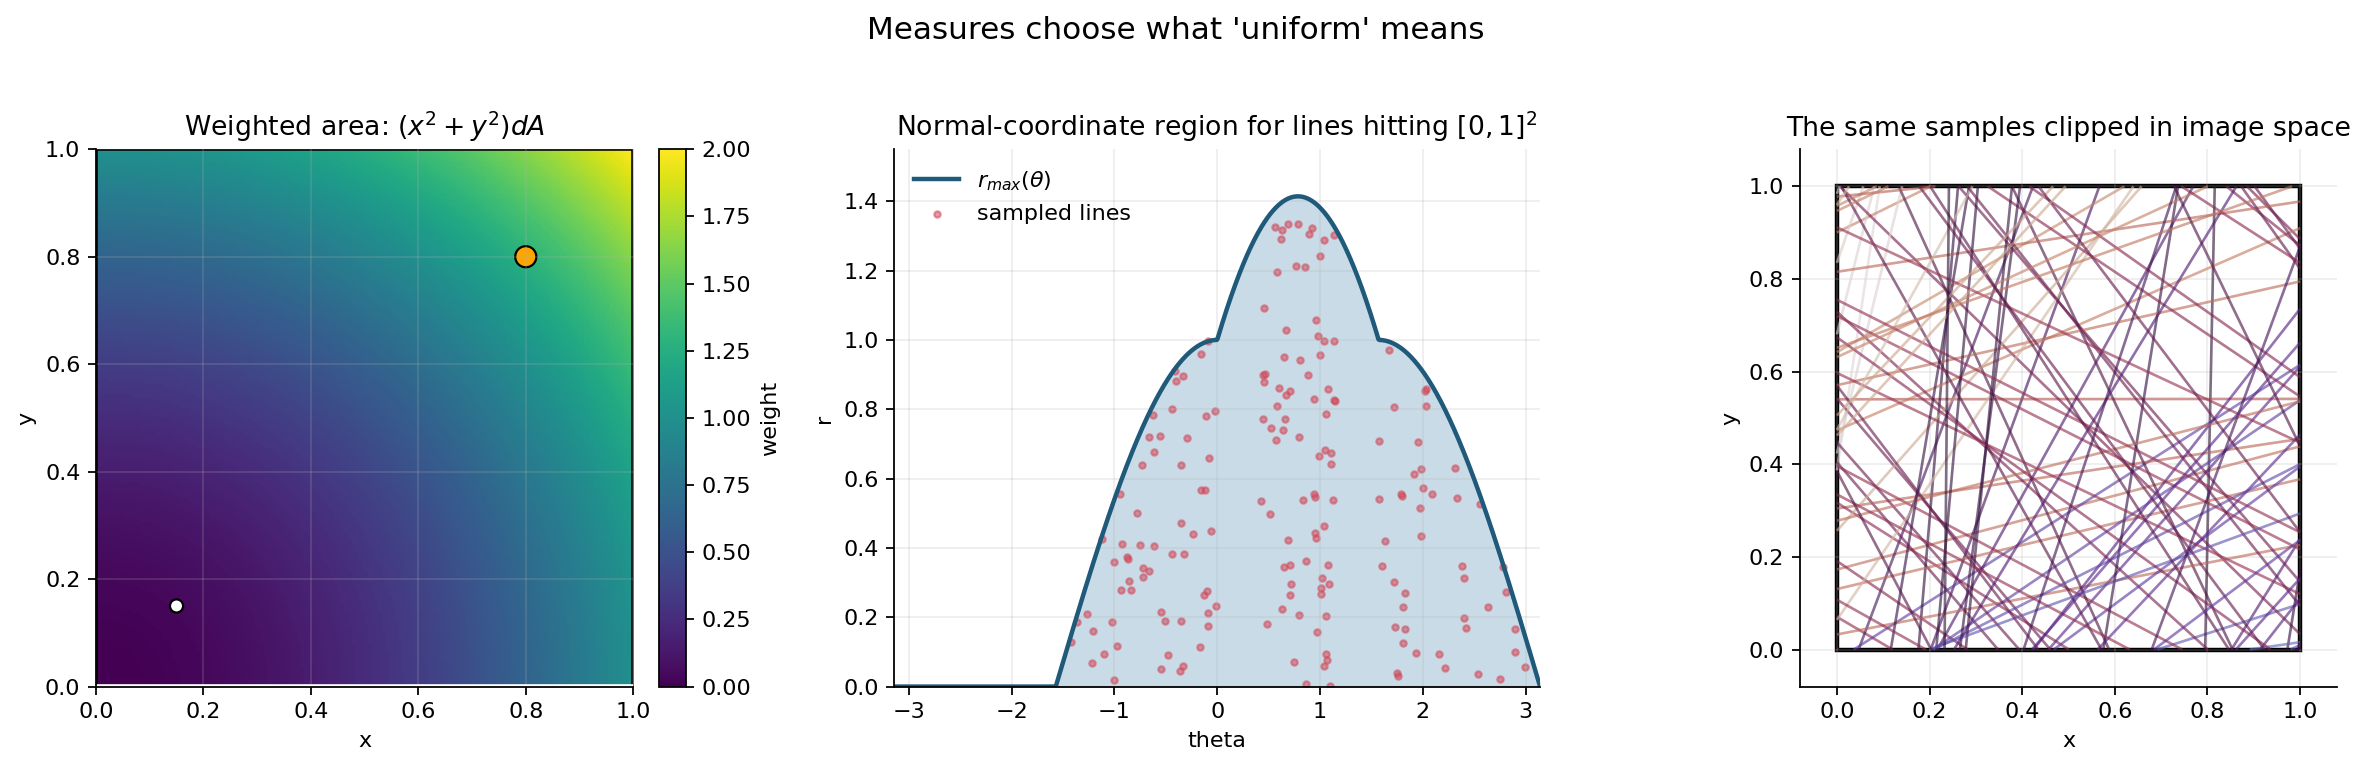

{'unit_square_area': 1.0,
 'weighted_square_measure': 0.6666666666666666,
 'average_x_squared_on_0_2_square': 1.3333333333333333,
 'line_space_area_integral': 4.0,
 'expected_line_space_area': 4.0,
 'line_space_area_abs_error': 0.0,
 'sampled_line_count': 700,
 'valid_clipped_line_count': 700,
 'mean_clipped_line_length': 0.7537307135897965,
 'min_clipped_line_length': 0.003793903891710949}

In [3]:
x, y, theta_symbol = sp.symbols("x y theta", real=True)
unit_square_area = sp.integrate(1, (x, 0, 1), (y, 0, 1))
weighted_square_measure = sp.integrate(x**2 + y**2, (x, 0, 1), (y, 0, 1))
average_x2_on_two_square = sp.integrate(x**2, (x, 0, 2), (y, 0, 2)) / sp.integrate(1, (x, 0, 2), (y, 0, 2))
line_space_area, _ = integrate.quad(lambda t: float(rmax_theta(np.array([t]))[0]), -np.pi, np.pi, epsabs=1e-12)

u_line = RNG.random(700)
v_line = RNG.random(700)
line_theta, line_r = sample_square_lines(u_line, v_line)
segments = [line_segment_in_unit_square(t, r) for t, r in zip(line_theta, line_r)]
valid_segments = [segment for segment in segments if segment is not None]
line_lengths = np.array([np.linalg.norm(segment[1] - segment[0]) for segment in valid_segments])

grid = np.linspace(0.0, 1.0, 160)
X, Y = np.meshgrid(grid, grid)
W = X**2 + Y**2
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7))

im = axes[0].imshow(W, origin="lower", extent=(0, 1, 0, 1), cmap="viridis")
axes[0].add_patch(Rectangle((0, 0), 1, 1, fill=False, lw=1.6, color="black"))
axes[0].plot([0, 1], [0, 0], color="white", lw=3.0, label="zero-area edge")
axes[0].scatter([0.15, 0.8], [0.15, 0.8], s=[35, 90], c=["white", "orange"], edgecolors="black")
axes[0].set_title("Weighted area: $(x^2+y^2)dA$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="weight")

theta_grid = np.linspace(-np.pi, np.pi, 900)
r_boundary = rmax_theta(theta_grid)
axes[1].fill_between(theta_grid, 0, r_boundary, color="#7aa6c2", alpha=0.4)
axes[1].plot(theta_grid, r_boundary, color="#1f5a7a", lw=2.0, label="$r_{max}(\\theta)$")
axes[1].scatter(line_theta[:180], line_r[:180], s=8, color="#d1495b", alpha=0.55, label="sampled lines")
axes[1].set_title("Normal-coordinate region for lines hitting $[0,1]^2$")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("r")
axes[1].set_xlim(-np.pi, np.pi)
axes[1].set_ylim(0, 1.55)
axes[1].legend(loc="upper left", frameon=False)

sample_segments = valid_segments[:95]
colors = plt.cm.twilight((line_theta[:len(sample_segments)] + np.pi) / (2.0 * np.pi))
axes[2].add_collection(LineCollection(sample_segments, colors=colors, linewidths=1.2, alpha=0.62))
axes[2].add_patch(Rectangle((0, 0), 1, 1, fill=False, lw=2.0, color="black"))
axes[2].set_title("The same samples clipped in image space")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_xlim(-0.08, 1.08)
axes[2].set_ylim(-0.08, 1.08)
axes[2].set_aspect("equal")

fig.suptitle("Measures choose what 'uniform' means", y=1.02, fontsize=14)
fig.tight_layout()
measure_fig = record_artifact(save_matplotlib(fig, TOPIC, "measure-weighted-area-and-line-space.png"), "png")
plt.close(fig)

measure_checks = {
    "unit_square_area": float(unit_square_area),
    "weighted_square_measure": float(weighted_square_measure),
    "average_x_squared_on_0_2_square": float(average_x2_on_two_square),
    "line_space_area_integral": float(line_space_area),
    "expected_line_space_area": 4.0,
    "line_space_area_abs_error": float(abs(line_space_area - 4.0)),
    "sampled_line_count": int(len(line_theta)),
    "valid_clipped_line_count": int(len(valid_segments)),
    "mean_clipped_line_length": float(line_lengths.mean()),
    "min_clipped_line_length": float(line_lengths.min()),
}
measure_check_path = save_check(measure_checks, "measure-line-space-checks.json")

display_artifact(measure_fig, width=980)
display_artifact(measure_check_path)
measure_checks


## Inverse CDF: move uniform samples without changing the intended measure

The inverse-CDF method starts with canonical uniform samples and bends the coordinate so that intervals with more target density receive more samples. For the density `p(x) = 3x^2/2` on `[-1, 1]`, the CDF is `(x^3 + 1)/2`, so the inverse warp is `x = cbrt(2u - 1)`.

The disk example is the same idea in polar coordinates. Uniform disk samples are uniform with respect to area `dA = r dr dphi`, so the radius cannot be sampled uniformly. The radius must be `sqrt(u)`, otherwise too much mass lands near the center.


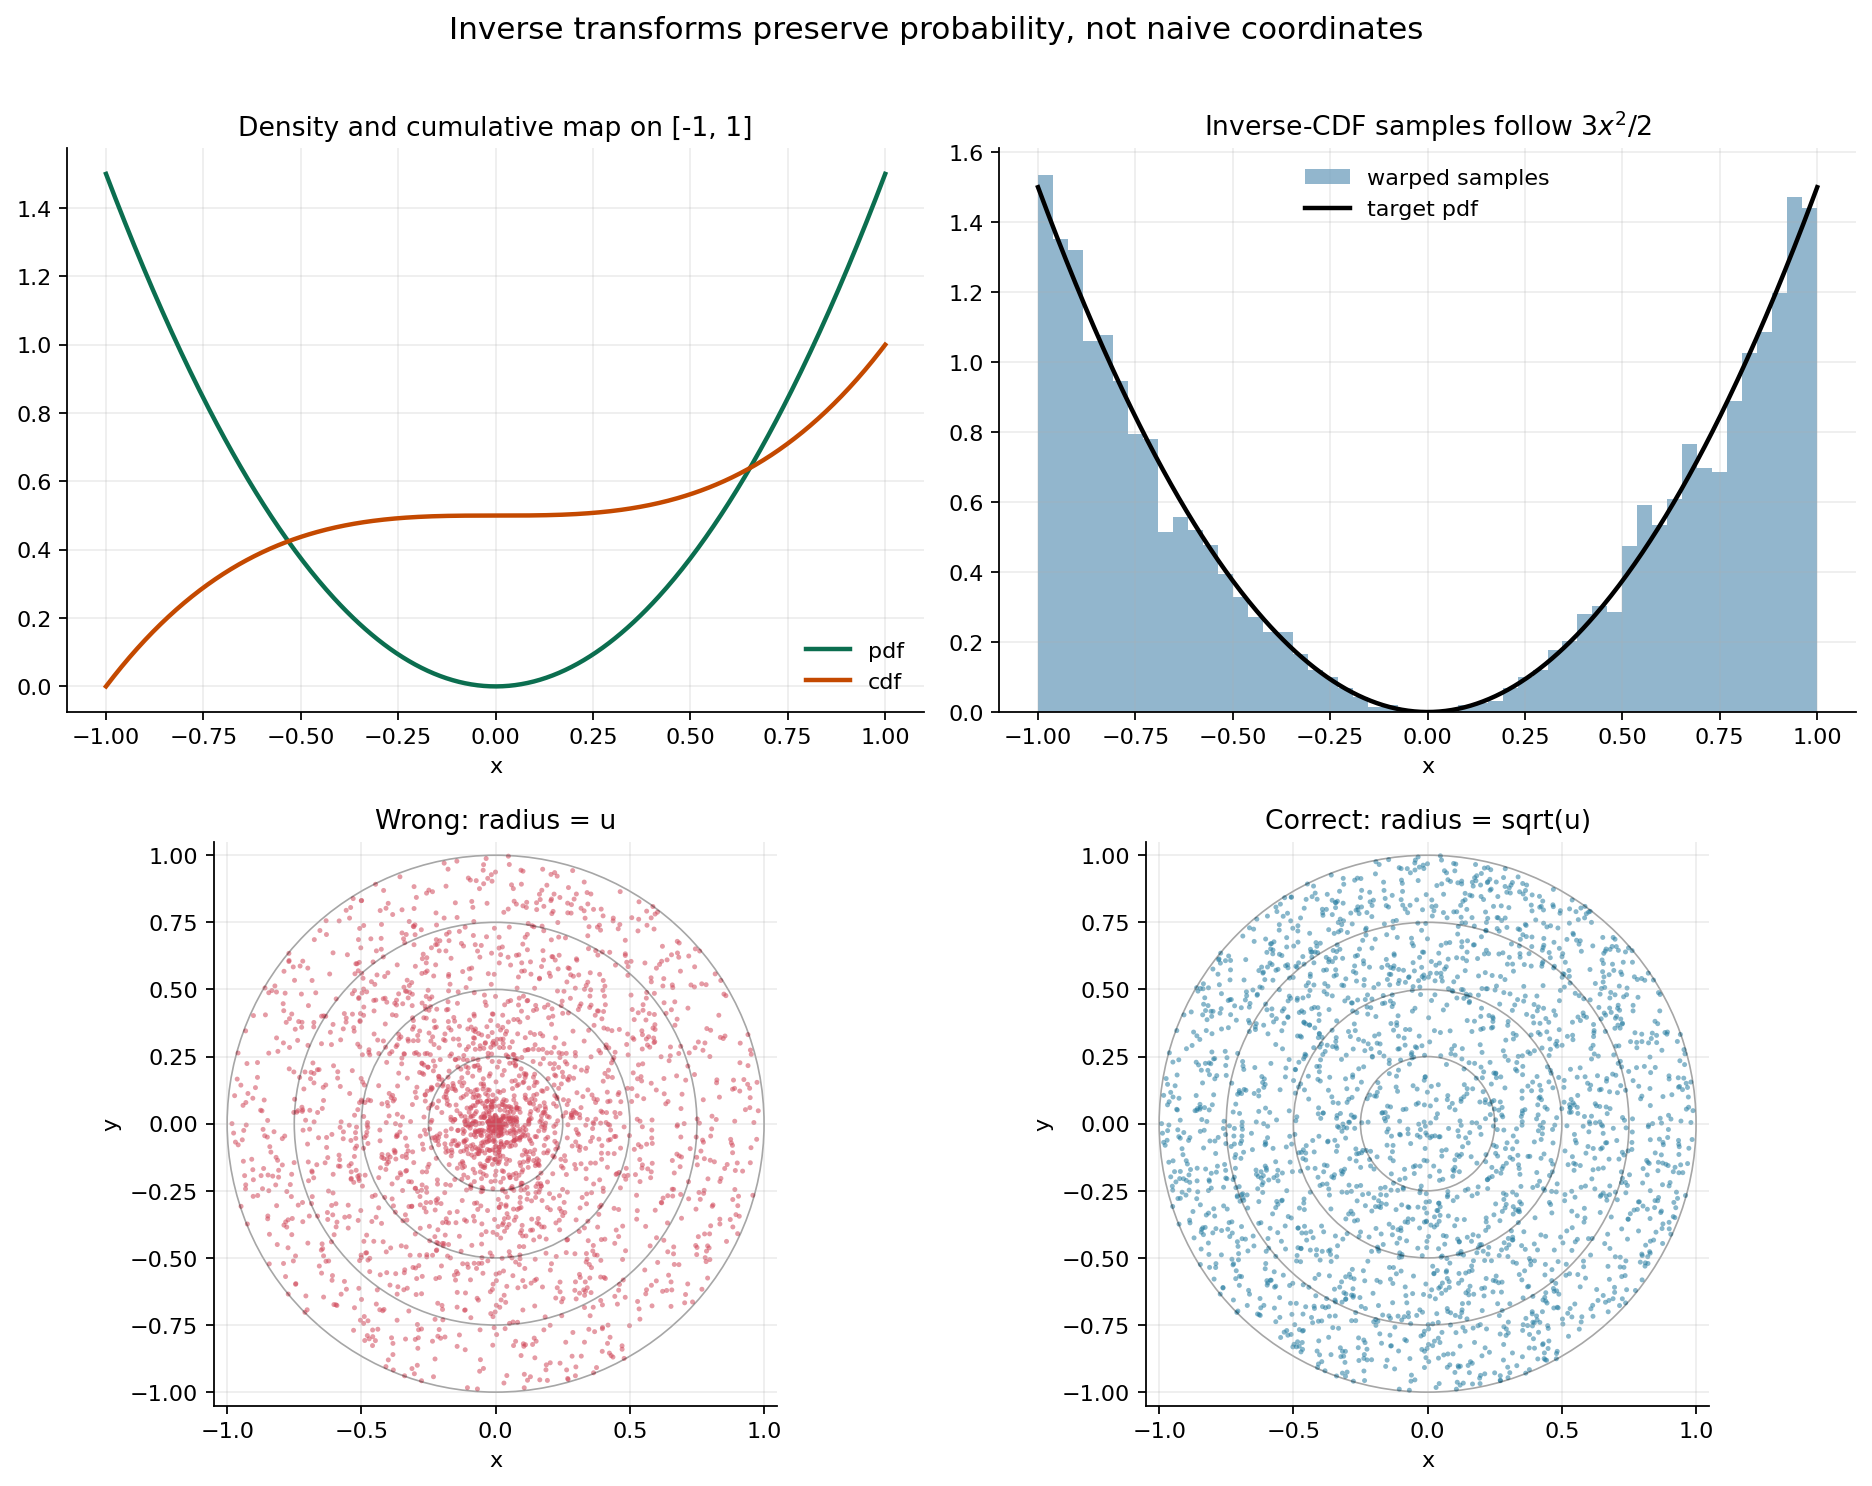

{'cubic_pdf_integral': 1.0,
 'cubic_inverse_cdf_error': 0.009783733102462444,
 'disk_radial_cdf_error_correct': 0.010904764310865844,
 'disk_radial_cdf_error_naive': 0.25108511217675267,
 'inner_half_radius_probability_correct': 0.2525,
 'inner_half_radius_probability_naive': 0.49916666666666665,
 'expected_inner_half_radius_probability': 0.25}

In [4]:
u = RNG.random(5000)
x_warp = cubic_inverse(u)
x_grid = np.linspace(-1.0, 1.0, 500)
ks_cubic = float(np.max(np.abs(np.sort(cubic_cdf(x_warp)) - (np.arange(1, len(u) + 1) / len(u)))))

u_disk = RNG.random(2400)
v_disk = RNG.random(2400)
disk_good, r_good, _ = unit_disk_inverse(u_disk, v_disk)
disk_bad, r_bad, _ = unit_disk_naive(u_disk, v_disk)
good_radial_error = radial_cdf_error(disk_good)
bad_radial_error = radial_cdf_error(disk_bad)
inner_good = float(np.mean(np.linalg.norm(disk_good, axis=1) < 0.5))
inner_bad = float(np.mean(np.linalg.norm(disk_bad, axis=1) < 0.5))

fig, axes = plt.subplots(2, 2, figsize=(11.8, 9.2))
axes[0, 0].plot(x_grid, cubic_density(x_grid), color="#0b6e4f", lw=2.0, label="pdf")
axes[0, 0].plot(x_grid, cubic_cdf(x_grid), color="#c44900", lw=2.0, label="cdf")
axes[0, 0].set_title("Density and cumulative map on [-1, 1]")
axes[0, 0].set_xlabel("x")
axes[0, 0].legend(frameon=False)

axes[0, 1].hist(x_warp, bins=52, density=True, color="#7aa6c2", alpha=0.82, label="warped samples")
axes[0, 1].plot(x_grid, cubic_density(x_grid), color="black", lw=2.0, label="target pdf")
axes[0, 1].set_title("Inverse-CDF samples follow $3x^2/2$")
axes[0, 1].set_xlabel("x")
axes[0, 1].legend(frameon=False)

for ax, pts, title, color in [
    (axes[1, 0], disk_bad, "Wrong: radius = u", "#d1495b"),
    (axes[1, 1], disk_good, "Correct: radius = sqrt(u)", "#277da1"),
]:
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.55, color=color, edgecolors="none")
    for radius in (0.25, 0.5, 0.75, 1.0):
        ax.add_patch(Circle((0, 0), radius, fill=False, color="black", lw=0.75, alpha=0.35))
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")

fig.suptitle("Inverse transforms preserve probability, not naive coordinates", y=1.01, fontsize=14)
fig.tight_layout()
inverse_fig = record_artifact(save_matplotlib(fig, TOPIC, "inverse-cdf-disk-warp.png"), "png")
plt.close(fig)

inverse_checks = {
    "cubic_pdf_integral": float(integrate.quad(lambda z: cubic_density(z), -1.0, 1.0)[0]),
    "cubic_inverse_cdf_error": ks_cubic,
    "disk_radial_cdf_error_correct": good_radial_error,
    "disk_radial_cdf_error_naive": bad_radial_error,
    "inner_half_radius_probability_correct": inner_good,
    "inner_half_radius_probability_naive": inner_bad,
    "expected_inner_half_radius_probability": 0.25,
}
inverse_check_path = save_check(inverse_checks, "inverse-cdf-disk-checks.json")

display_artifact(inverse_fig, width=860)
display_artifact(inverse_check_path)
inverse_checks


## Rejection and Metropolis: useful fallbacks with visible costs

Rejection sampling proposes from a simple distribution and keeps only points that lie under the desired shape. It is easy to write and often good for debugging. Its weakness is also visible: rejected samples waste work, and the unpredictable accept/reject step breaks a carefully stratified pattern.

Metropolis sampling is different. It mutates a current sample and accepts or rejects the move so that the long-run population follows a target density. It can sample densities known only up to a scale factor, but the samples are correlated and a burn-in choice becomes part of the method.


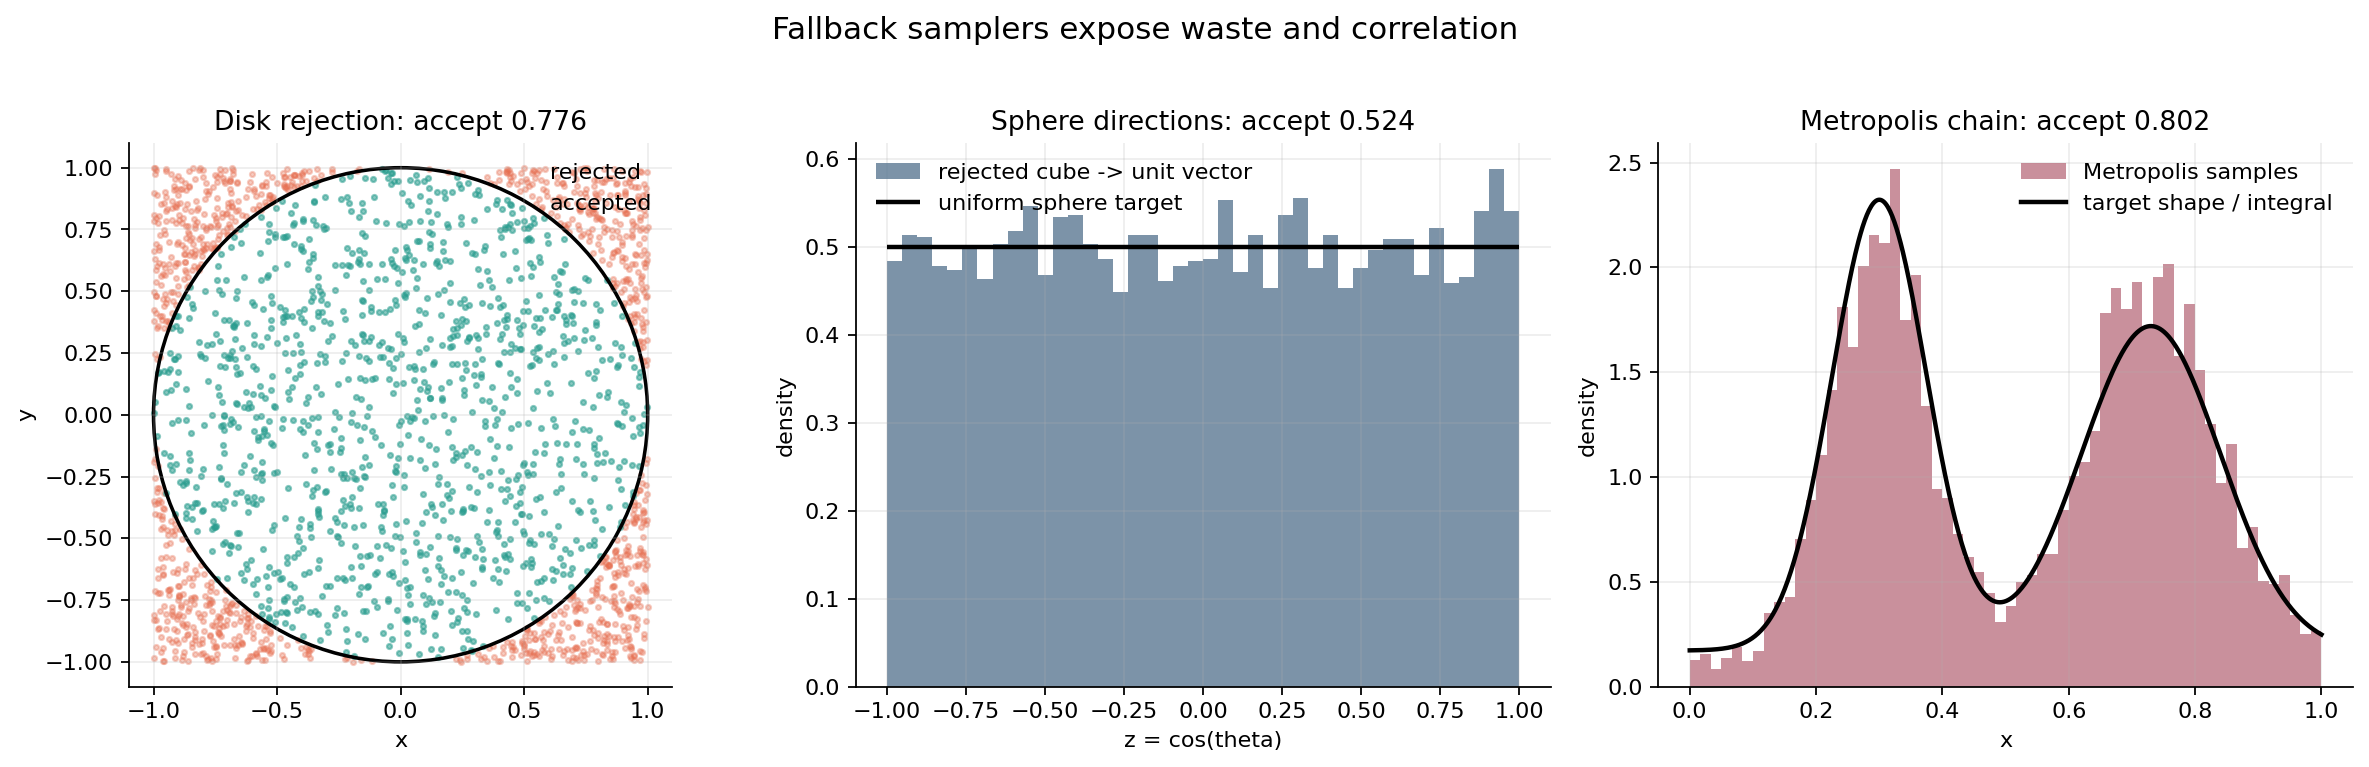

{'disk_acceptance': 0.7764,
 'expected_disk_acceptance': 0.7853981633974483,
 'disk_acceptance_abs_error': 0.0089981633974483,
 'sphere_acceptance': 0.5240625,
 'expected_sphere_acceptance': 0.5235987755982988,
 'sphere_acceptance_abs_error': 0.000463724401701171,
 'sphere_z_cdf_error': 0.008590373923728079,
 'metropolis_acceptance': 0.8018421052631579,
 'metropolis_sample_mean': 0.5305621827353311,
 'target_mean_numeric': 0.5157248181580559,
 'metropolis_mean_abs_error': 0.014837364577275136}

In [5]:
candidates = RNG.uniform(-1.0, 1.0, size=(5000, 2))
r2 = np.sum(candidates**2, axis=1)
accepted_disk = candidates[r2 <= 1.0]
rejected_disk = candidates[r2 > 1.0]
disk_acceptance = float(len(accepted_disk) / len(candidates))

cube_candidates = RNG.uniform(-1.0, 1.0, size=(16000, 3))
inside = np.sum(cube_candidates**2, axis=1) <= 1.0
sphere_points = cube_candidates[inside]
sphere_dirs_rejection = sphere_points / np.linalg.norm(sphere_points, axis=1, keepdims=True)
sphere_acceptance = float(np.mean(inside))
sphere_z_error = float(np.max(np.abs(np.sort((sphere_dirs_rejection[:, 2] + 1.0) / 2.0) - (np.arange(1, len(sphere_dirs_rejection) + 1) / len(sphere_dirs_rejection)))))


def target_unnormalized(values):
    values = np.asarray(values)
    return 0.08 + np.exp(-0.5 * ((values - 0.30) / 0.075) ** 2) + 0.72 * np.exp(-0.5 * ((values - 0.73) / 0.11) ** 2)


def reflect_unit_interval(values):
    values = np.asarray(values)
    values = np.where(values < 0.0, -values, values)
    values = np.where(values > 1.0, 2.0 - values, values)
    return np.clip(values, 0.0, 1.0)


def metropolis_chain(n=7000, burn=600, step=0.08):
    x_current = 0.12
    samples = []
    accepted = 0
    total = n + burn
    for index in range(total):
        proposal = float(reflect_unit_interval(x_current + RNG.normal(0.0, step)))
        ratio = target_unnormalized(proposal) / target_unnormalized(x_current)
        if RNG.random() < min(1.0, float(ratio)):
            x_current = proposal
            accepted += 1
        if index >= burn:
            samples.append(x_current)
    return np.array(samples), accepted / total


metropolis_samples, metropolis_acceptance = metropolis_chain()
metropolis_grid = np.linspace(0.0, 1.0, 600)
target_values = target_unnormalized(metropolis_grid)
target_normalizer = integrate.trapezoid(target_values, metropolis_grid)
target_pdf_values = target_values / target_normalizer
metropolis_mean = float(metropolis_samples.mean())
target_mean = float(integrate.trapezoid(metropolis_grid * target_pdf_values, metropolis_grid))

fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.7))
axes[0].scatter(rejected_disk[:1200, 0], rejected_disk[:1200, 1], s=5, color="#e76f51", alpha=0.35, label="rejected")
axes[0].scatter(accepted_disk[:1200, 0], accepted_disk[:1200, 1], s=5, color="#2a9d8f", alpha=0.55, label="accepted")
axes[0].add_patch(Circle((0, 0), 1, fill=False, color="black", lw=1.6))
axes[0].set_title(f"Disk rejection: accept {disk_acceptance:.3f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].legend(frameon=False, loc="upper right")

axes[1].hist(sphere_dirs_rejection[:, 2], bins=42, density=True, color="#577590", alpha=0.78, label="rejected cube -> unit vector")
axes[1].hlines(0.5, -1, 1, color="black", lw=2.0, label="uniform sphere target")
axes[1].set_title(f"Sphere directions: accept {sphere_acceptance:.3f}")
axes[1].set_xlabel("z = cos(theta)")
axes[1].set_ylabel("density")
axes[1].legend(frameon=False)

axes[2].hist(metropolis_samples, bins=60, density=True, color="#b56576", alpha=0.72, label="Metropolis samples")
axes[2].plot(metropolis_grid, target_pdf_values, color="black", lw=2.0, label="target shape / integral")
axes[2].set_title(f"Metropolis chain: accept {metropolis_acceptance:.3f}")
axes[2].set_xlabel("x")
axes[2].set_ylabel("density")
axes[2].legend(frameon=False)

fig.suptitle("Fallback samplers expose waste and correlation", y=1.02, fontsize=14)
fig.tight_layout()
rejection_fig = record_artifact(save_matplotlib(fig, TOPIC, "rejection-metropolis-diagnostics.png"), "png")
plt.close(fig)

rejection_checks = {
    "disk_acceptance": disk_acceptance,
    "expected_disk_acceptance": float(np.pi / 4.0),
    "disk_acceptance_abs_error": float(abs(disk_acceptance - np.pi / 4.0)),
    "sphere_acceptance": sphere_acceptance,
    "expected_sphere_acceptance": float(np.pi / 6.0),
    "sphere_acceptance_abs_error": float(abs(sphere_acceptance - np.pi / 6.0)),
    "sphere_z_cdf_error": sphere_z_error,
    "metropolis_acceptance": float(metropolis_acceptance),
    "metropolis_sample_mean": metropolis_mean,
    "target_mean_numeric": target_mean,
    "metropolis_mean_abs_error": float(abs(metropolis_mean - target_mean)),
}
rejection_check_path = save_check(rejection_checks, "rejection-metropolis-checks.json")

display_artifact(rejection_fig, width=980)
display_artifact(rejection_check_path)
rejection_checks


## Variance and coverage diagnostics

Monte Carlo estimates trade sample count for uncertainty. If the estimator uses samples from density `p`, the value averaged is `g(x) / p(x)`. This means a density with the same shape as the integrand reduces variance, and a perfect normalized match can make the estimator constant.

Stratification attacks a different source of error: coverage. Instead of hoping iid samples spread out, it forces one sample into each region. The figure compares repeated estimates of `int_0^4 x dx = 8` and then shows why random, jittered, and Sobol-like coverage patterns behave differently in a unit square.


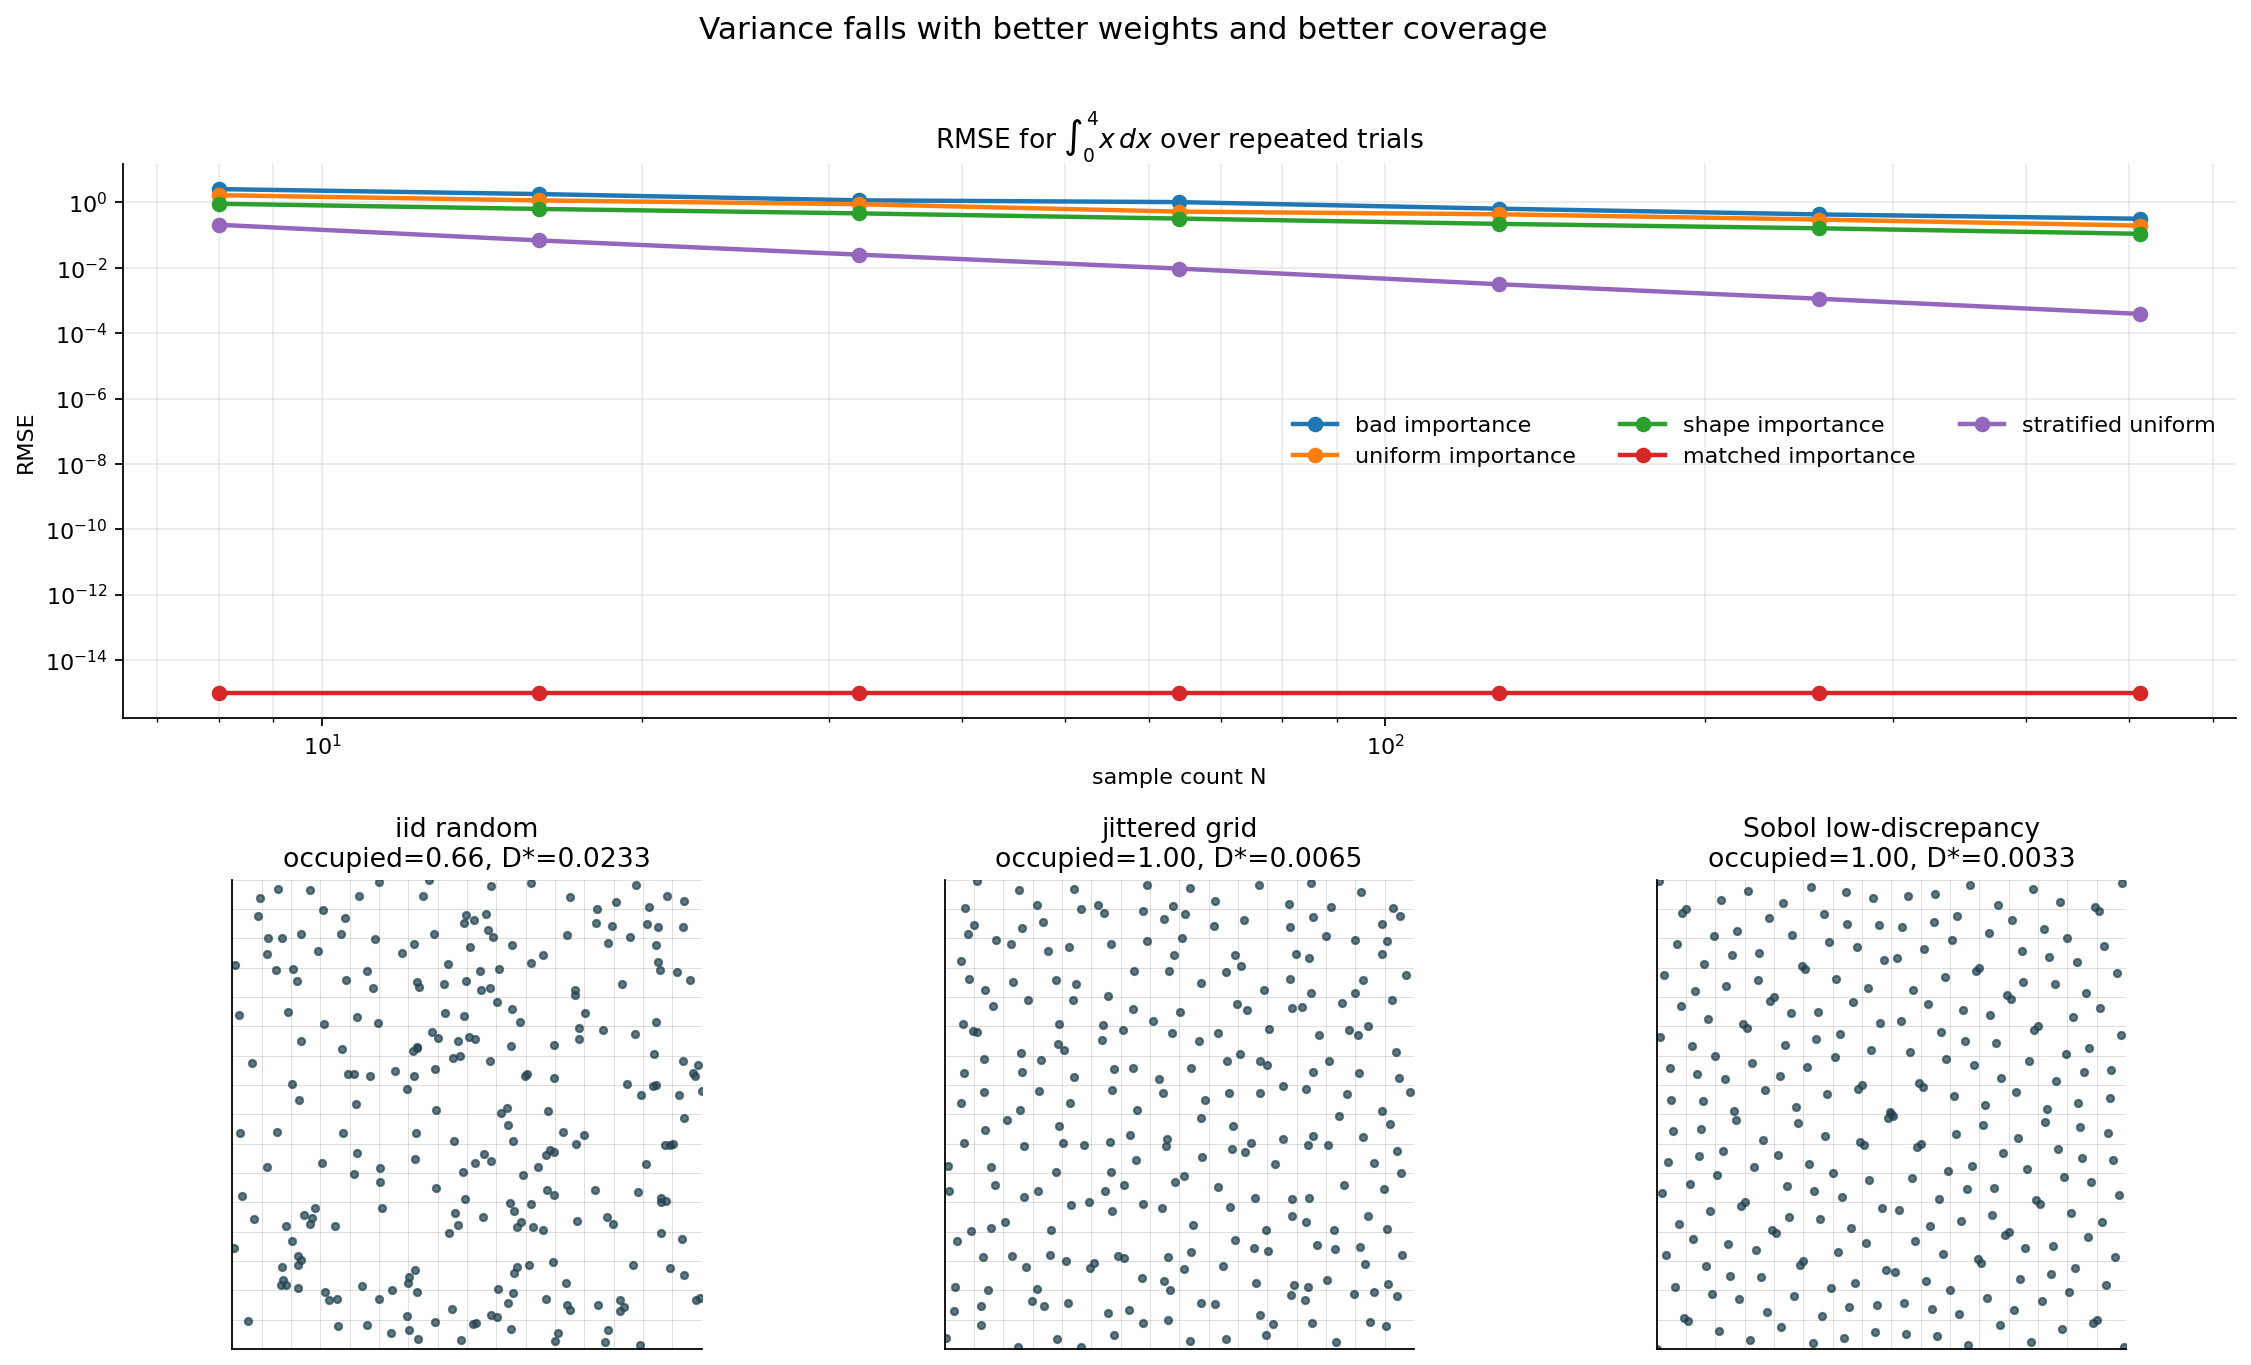

method,bad importance,matched importance,shape importance,stratified uniform,uniform importance
sample_count,,,,,
8,2.567303,0.0,0.914926,0.207621,1.674623
16,1.810894,0.0,0.635215,0.069023,1.158216
32,1.163628,0.0,0.464249,0.025316,0.886486
64,1.027486,0.0,0.322042,0.009476,0.525498
128,0.646206,0.0,0.221542,0.003143,0.436329
256,0.431288,0.0,0.162245,0.001131,0.299922
512,0.318147,0.0,0.110056,0.000390,0.196413


,point_count,occupied_fraction,max_relative_cell_error,l2_star_discrepancy,minimum_pair_distance,pattern
0,256,0.66016,3.0,0.02331,0.00249,iid random
1,256,1.00000,0.0,0.00652,0.00792,jittered grid
2,256,1.00000,0.0,0.00331,0.00552,Sobol low-discrepancy


{'true_integral_x_on_0_4': 8.0,
 'uniform_rmse_N512': 0.196412929533991,
 'stratified_rmse_N512': 0.0003897507273336615,
 'matched_importance_max_rmse': 0.0,
 'jittered_occupied_fraction': 1.0,
 'random_occupied_fraction': 0.66015625,
 'sobol_l2_star_discrepancy': 0.0033074703678268075,
 'random_l2_star_discrepancy': 0.02330586709972805,
 'variance_table': 'artifacts/chapter-13/tables/variance-convergence.csv',
 'coverage_table': 'artifacts/chapter-13/tables/coverage-diagnostics.csv'}

In [6]:
TRUE_INTEGRAL = 8.0
sample_counts = np.array([8, 16, 32, 64, 128, 256, 512])
trial_count = 260


def estimate_integral_once(method, n):
    u = RNG.random(n)
    if method == "bad importance":
        x_sample = 6.0 - np.sqrt(36.0 - 32.0 * u)
        p = (6.0 - x_sample) / 16.0
    elif method == "uniform importance":
        x_sample = 4.0 * u
        p = np.full(n, 0.25)
    elif method == "shape importance":
        x_sample = -2.0 + np.sqrt(4.0 + 32.0 * u)
        p = (x_sample + 2.0) / 16.0
    elif method == "matched importance":
        x_sample = 4.0 * np.sqrt(u)
        p = np.maximum(x_sample / 8.0, 1e-15)
    elif method == "stratified uniform":
        x_sample = 4.0 * ((np.arange(n) + u) / n)
        p = np.full(n, 0.25)
    else:
        raise ValueError(method)
    return float(np.mean(x_sample / p))


methods = ["bad importance", "uniform importance", "shape importance", "matched importance", "stratified uniform"]
convergence_rows = []
rmse_by_method = {method: [] for method in methods}
for n in sample_counts:
    for method in methods:
        estimates = np.array([estimate_integral_once(method, int(n)) for _ in range(trial_count)])
        rmse = float(np.sqrt(np.mean((estimates - TRUE_INTEGRAL) ** 2)))
        rmse_by_method[method].append(rmse)
        convergence_rows.append({
            "method": method,
            "sample_count": int(n),
            "mean_estimate": float(estimates.mean()),
            "rmse": rmse,
            "sample_variance": float(estimates.var(ddof=1)),
        })

convergence_path = record_artifact(save_table_csv(convergence_rows, TOPIC, "variance-convergence.csv"), "table")

bins = 16
n2 = bins * bins
random_points = RNG.random((n2, 2))
cell = np.arange(bins)
GX, GY = np.meshgrid(cell, cell)
jittered_points = np.column_stack(((GX.ravel() + RNG.random(n2)) / bins, (GY.ravel() + RNG.random(n2)) / bins))
sobol_points = qmc.Sobol(d=2, scramble=False).random_base2(m=int(np.log2(n2)))
patterns = {
    "iid random": random_points,
    "jittered grid": jittered_points,
    "Sobol low-discrepancy": sobol_points,
}
coverage_rows = []
for name, points in patterns.items():
    stats = grid_coverage_stats(points, bins=bins)
    stats["pattern"] = name
    coverage_rows.append(stats)
coverage_path = record_artifact(save_table_csv(coverage_rows, TOPIC, "coverage-diagnostics.csv"), "table")

fig = plt.figure(figsize=(14.2, 8.4))
gs = fig.add_gridspec(2, 3, height_ratios=[1.18, 1.0])
ax_rmse = fig.add_subplot(gs[0, :])
for method, values in rmse_by_method.items():
    plot_values = np.maximum(np.array(values), 1e-15)
    ax_rmse.loglog(sample_counts, plot_values, marker="o", lw=2.0, label=method)
ax_rmse.set_title("RMSE for $\\int_0^4 x\\,dx$ over repeated trials")
ax_rmse.set_xlabel("sample count N")
ax_rmse.set_ylabel("RMSE")
ax_rmse.legend(ncol=3, frameon=False)
ax_rmse.grid(True, which="both", alpha=0.25)

for ax, (name, points) in zip([fig.add_subplot(gs[1, i]) for i in range(3)], patterns.items()):
    ax.scatter(points[:, 0], points[:, 1], s=10, color="#264653", alpha=0.72)
    for k in range(bins + 1):
        ax.axhline(k / bins, color="black", lw=0.35, alpha=0.16)
        ax.axvline(k / bins, color="black", lw=0.35, alpha=0.16)
    stats = next(row for row in coverage_rows if row["pattern"] == name)
    ax.set_title(f"{name}\noccupied={stats['occupied_fraction']:.2f}, D*={stats['l2_star_discrepancy']:.4f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Variance falls with better weights and better coverage", y=1.01, fontsize=14)
fig.tight_layout()
variance_fig = record_artifact(save_matplotlib(fig, TOPIC, "variance-stratification-coverage.png"), "png")
plt.close(fig)

coverage_by_name = {row["pattern"]: row for row in coverage_rows}
variance_checks = {
    "true_integral_x_on_0_4": TRUE_INTEGRAL,
    "uniform_rmse_N512": float(rmse_by_method["uniform importance"][-1]),
    "stratified_rmse_N512": float(rmse_by_method["stratified uniform"][-1]),
    "matched_importance_max_rmse": float(np.max(rmse_by_method["matched importance"])),
    "jittered_occupied_fraction": coverage_by_name["jittered grid"]["occupied_fraction"],
    "random_occupied_fraction": coverage_by_name["iid random"]["occupied_fraction"],
    "sobol_l2_star_discrepancy": coverage_by_name["Sobol low-discrepancy"]["l2_star_discrepancy"],
    "random_l2_star_discrepancy": coverage_by_name["iid random"]["l2_star_discrepancy"],
    "variance_table": book_relative(convergence_path),
    "coverage_table": book_relative(coverage_path),
}
variance_check_path = save_check(variance_checks, "variance-coverage-checks.json")

display_artifact(variance_fig, width=980)
display(pd.DataFrame(convergence_rows).pivot(index="sample_count", columns="method", values="rmse").round(6))
display(pd.DataFrame(coverage_rows).round(5))
display_artifact(variance_check_path)
variance_checks


## Line, disk, sphere, and hemisphere sampling as geometric maps

The chapter's examples all have the same shape: start with canonical random numbers, then preserve the right measure for the target geometry.

- A disk uses polar area `r dr dphi`, so `r = sqrt(u)`.
- A sphere uses solid angle. Uniform sphere directions have `z = cos(theta)` uniform on `[-1, 1]`.
- A hemisphere has `z` uniform on `[0, 1]` when the density is uniform over solid angle.
- A cosine or Phong-like hemisphere density uses `p(omega) = (n + 1) z^n / (2 pi)`, so `z = (1-u)^(1/(n+1))`.

The interactive artifact below lets the learner rotate the point clouds; the static marginal plot makes the density difference explicit.


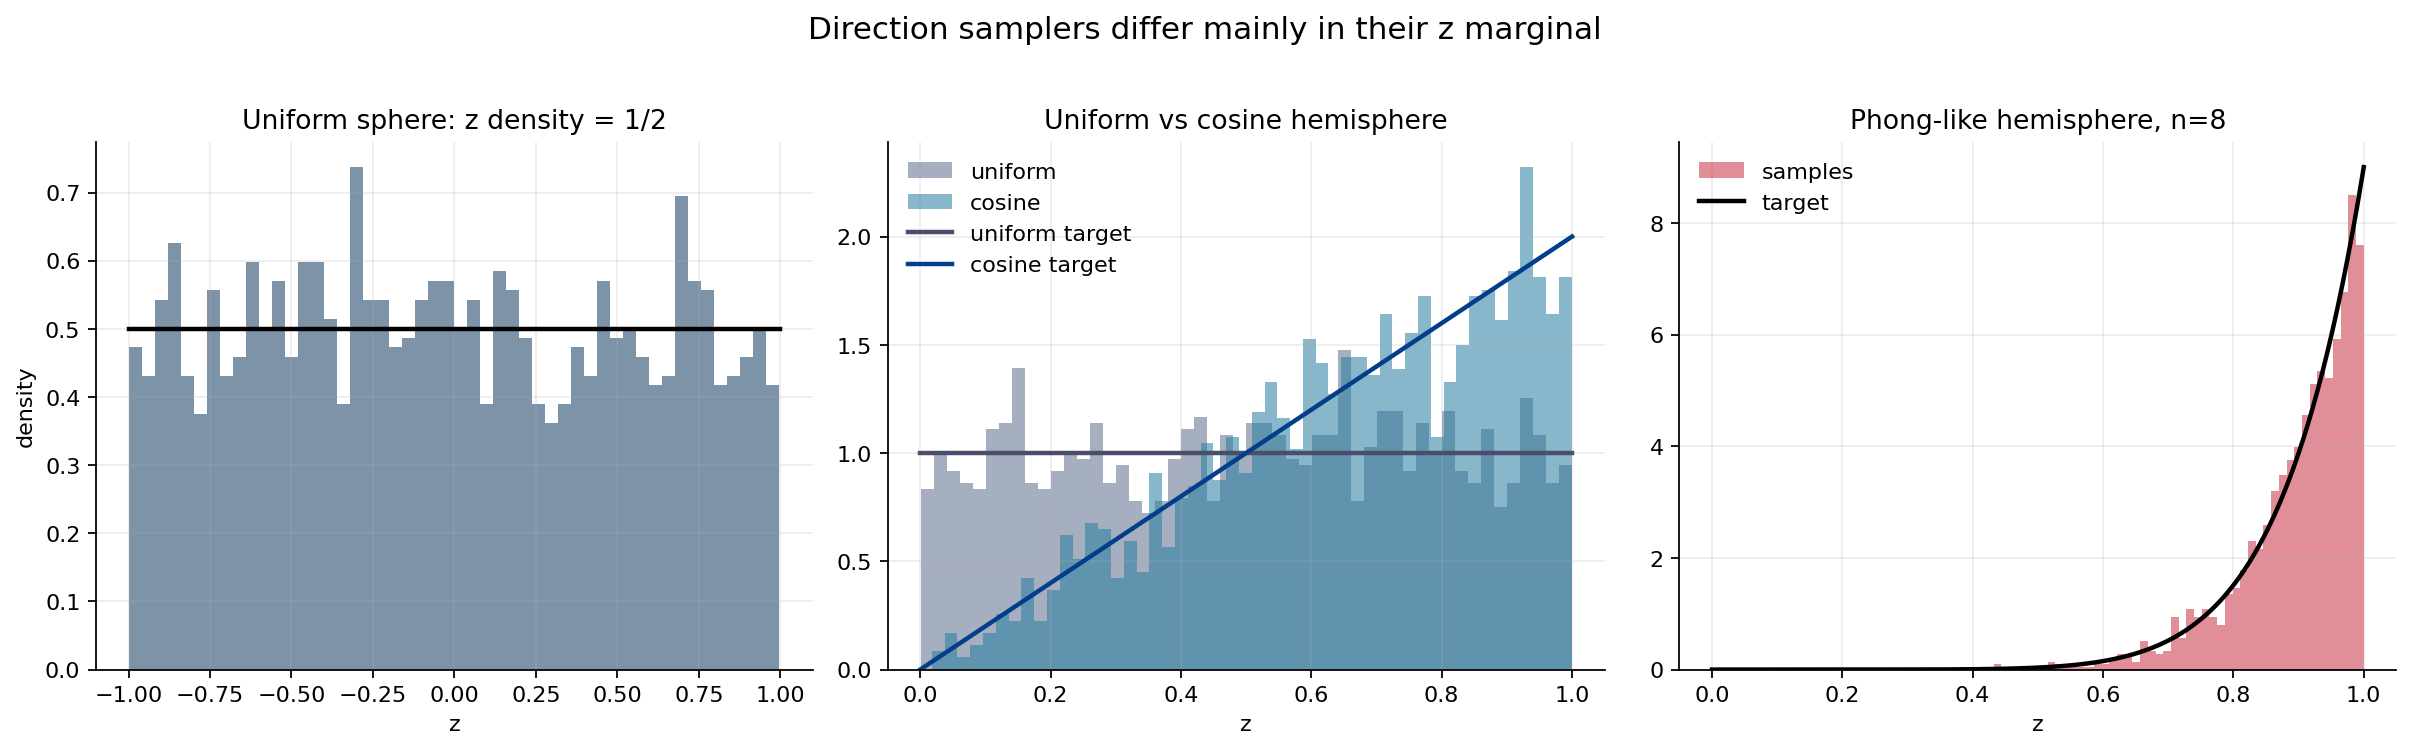

{'max_norm_error': 2.220446049250313e-16,
 'sphere_mean_z': -0.014535220370801348,
 'uniform_hemisphere_mean_z': 0.5072676101854007,
 'cosine_hemisphere_mean_z': 0.6623021950912782,
 'expected_cosine_hemisphere_mean_z': 0.6666666666666666,
 'phong_exponent': 8.0,
 'phong_mean_z': 0.8990207291504427,
 'expected_phong_mean_z': 0.9,
 'hemisphere_min_z': 0.0013301993628802578,
 'interactive_html': 'artifacts/chapter-13/html/sphere-hemisphere-direction-sampling.html',
 'marginal_png': 'artifacts/chapter-13/figures/sphere-hemisphere-direction-marginals.png'}

In [7]:
n_dir = 1800
uv = RNG.random((n_dir, 2))
sphere_dirs = sphere_uniform(uv[:, 0], uv[:, 1])
hemisphere_dirs = hemisphere_uniform(uv[:, 0], uv[:, 1])
cosine_dirs = hemisphere_phong(uv[:, 0], uv[:, 1], exponent=1.0)
phong_exponent = 8.0
phong_dirs = hemisphere_phong(uv[:, 0], uv[:, 1], exponent=phong_exponent)

fig3d = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Uniform sphere directions", "Hemisphere densities"),
)
sub = slice(None, None, 3)
fig3d.add_trace(
    go.Scatter3d(
        x=sphere_dirs[sub, 0], y=sphere_dirs[sub, 1], z=sphere_dirs[sub, 2],
        mode="markers", marker={"size": 2.5, "color": sphere_dirs[sub, 2], "colorscale": "Viridis", "opacity": 0.72},
        name="sphere uniform",
    ),
    row=1,
    col=1,
)
fig3d.add_trace(
    go.Scatter3d(
        x=hemisphere_dirs[sub, 0], y=hemisphere_dirs[sub, 1], z=hemisphere_dirs[sub, 2],
        mode="markers", marker={"size": 2.5, "color": "#8d99ae", "opacity": 0.42},
        name="uniform hemisphere",
    ),
    row=1,
    col=2,
)
fig3d.add_trace(
    go.Scatter3d(
        x=cosine_dirs[sub, 0], y=cosine_dirs[sub, 1], z=cosine_dirs[sub, 2],
        mode="markers", marker={"size": 2.4, "color": "#277da1", "opacity": 0.55},
        name="cosine hemisphere",
    ),
    row=1,
    col=2,
)
fig3d.add_trace(
    go.Scatter3d(
        x=phong_dirs[sub, 0], y=phong_dirs[sub, 1], z=phong_dirs[sub, 2],
        mode="markers", marker={"size": 2.2, "color": "#d1495b", "opacity": 0.58},
        name="Phong n=8",
    ),
    row=1,
    col=2,
)
for scene_name in ("scene", "scene2"):
    fig3d.update_layout(**{
        scene_name: {
            "xaxis": {"range": [-1, 1], "title": "x"},
            "yaxis": {"range": [-1, 1], "title": "y"},
            "zaxis": {"range": [-1, 1], "title": "z"},
            "aspectmode": "cube",
        }
    })
fig3d.update_layout(height=560, margin={"l": 0, "r": 0, "b": 0, "t": 45}, legend={"orientation": "h", "y": -0.08})
html_path = record_artifact(save_plotly_html(fig3d, TOPIC, "sphere-hemisphere-direction-sampling.html"), "html")

z_grid_sphere = np.linspace(-1.0, 1.0, 400)
z_grid_hemi = np.linspace(0.0, 1.0, 400)
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.6))
axes[0].hist(sphere_dirs[:, 2], bins=50, density=True, color="#577590", alpha=0.78)
axes[0].plot(z_grid_sphere, np.full_like(z_grid_sphere, 0.5), color="black", lw=2.0)
axes[0].set_title("Uniform sphere: z density = 1/2")
axes[0].set_xlabel("z")
axes[0].set_ylabel("density")

axes[1].hist(hemisphere_dirs[:, 2], bins=50, density=True, color="#8d99ae", alpha=0.78, label="uniform")
axes[1].hist(cosine_dirs[:, 2], bins=50, density=True, color="#277da1", alpha=0.55, label="cosine")
axes[1].plot(z_grid_hemi, np.ones_like(z_grid_hemi), color="#4a4e69", lw=2.0, label="uniform target")
axes[1].plot(z_grid_hemi, 2.0 * z_grid_hemi, color="#023e8a", lw=2.0, label="cosine target")
axes[1].set_title("Uniform vs cosine hemisphere")
axes[1].set_xlabel("z")
axes[1].legend(frameon=False)

axes[2].hist(phong_dirs[:, 2], bins=50, density=True, color="#d1495b", alpha=0.62, label="samples")
axes[2].plot(z_grid_hemi, (phong_exponent + 1.0) * z_grid_hemi**phong_exponent, color="black", lw=2.0, label="target")
axes[2].set_title("Phong-like hemisphere, n=8")
axes[2].set_xlabel("z")
axes[2].legend(frameon=False)

fig.suptitle("Direction samplers differ mainly in their z marginal", y=1.02, fontsize=14)
fig.tight_layout()
direction_fig = record_artifact(save_matplotlib(fig, TOPIC, "sphere-hemisphere-direction-marginals.png"), "png")
plt.close(fig)

norm_errors = {
    "sphere": float(np.max(np.abs(np.linalg.norm(sphere_dirs, axis=1) - 1.0))),
    "hemisphere": float(np.max(np.abs(np.linalg.norm(hemisphere_dirs, axis=1) - 1.0))),
    "cosine": float(np.max(np.abs(np.linalg.norm(cosine_dirs, axis=1) - 1.0))),
    "phong": float(np.max(np.abs(np.linalg.norm(phong_dirs, axis=1) - 1.0))),
}
direction_checks = {
    "max_norm_error": max(norm_errors.values()),
    "sphere_mean_z": float(sphere_dirs[:, 2].mean()),
    "uniform_hemisphere_mean_z": float(hemisphere_dirs[:, 2].mean()),
    "cosine_hemisphere_mean_z": float(cosine_dirs[:, 2].mean()),
    "expected_cosine_hemisphere_mean_z": 2.0 / 3.0,
    "phong_exponent": phong_exponent,
    "phong_mean_z": float(phong_dirs[:, 2].mean()),
    "expected_phong_mean_z": float((phong_exponent + 1.0) / (phong_exponent + 2.0)),
    "hemisphere_min_z": float(min(hemisphere_dirs[:, 2].min(), cosine_dirs[:, 2].min(), phong_dirs[:, 2].min())),
    "interactive_html": book_relative(html_path),
    "marginal_png": book_relative(direction_fig),
}
direction_check_path = save_check(direction_checks, "direction-sampling-checks.json")

display_artifact(html_path, width="100%", height=560)
display_artifact(direction_fig, width=980)
display_artifact(direction_check_path)
direction_checks


## Applied lab: choose a hemisphere density for an irradiance integral

A small rendering integral is enough to show why importance sampling matters. The diffuse irradiance factor over the upper hemisphere is

`I = int_H z d omega = pi`, where `z = cos(theta)`.

Uniform hemisphere sampling estimates this as `2 pi mean(z)`, so the estimator has visible variance. Cosine-weighted hemisphere sampling uses `p(omega) = z/pi`, and each sample contributes `z / (z/pi) = pi`. In exact arithmetic the variance is zero. The lab below repeats the experiment many times to make that difference measurable.


In [8]:
def hemisphere_integral_trials(n=96, trials=220):
    rows = []
    for trial in range(trials):
        uv_uniform = RNG.random((n, 2))
        dirs_uniform = hemisphere_uniform(uv_uniform[:, 0], uv_uniform[:, 1])
        uniform_estimate = float(np.mean(dirs_uniform[:, 2] / (1.0 / (2.0 * np.pi))))
        rows.append({"method": "uniform hemisphere", "trial": trial, "sample_count": n, "estimate": uniform_estimate})

        uv_cosine = RNG.random((n, 2))
        dirs_cosine = hemisphere_phong(uv_cosine[:, 0], uv_cosine[:, 1], exponent=1.0)
        cosine_pdf = np.maximum(dirs_cosine[:, 2] / np.pi, 1e-15)
        cosine_estimate = float(np.mean(dirs_cosine[:, 2] / cosine_pdf))
        rows.append({"method": "cosine-weighted hemisphere", "trial": trial, "sample_count": n, "estimate": cosine_estimate})

        side = int(np.sqrt(n))
        jitter_n = side * side
        gx, gy = np.meshgrid(np.arange(side), np.arange(side))
        uv_jitter = np.column_stack(((gx.ravel() + RNG.random(jitter_n)) / side, (gy.ravel() + RNG.random(jitter_n)) / side))
        dirs_jitter = hemisphere_phong(uv_jitter[:, 0], uv_jitter[:, 1], exponent=1.0)
        jitter_pdf = np.maximum(dirs_jitter[:, 2] / np.pi, 1e-15)
        jitter_estimate = float(np.mean(dirs_jitter[:, 2] / jitter_pdf))
        rows.append({"method": "jittered cosine warp", "trial": trial, "sample_count": jitter_n, "estimate": jitter_estimate})
    return rows


lab_rows = hemisphere_integral_trials()
lab_df = pd.DataFrame(lab_rows)
summary_df = (
    lab_df.groupby("method")
    .agg(sample_count=("sample_count", "first"), mean_estimate=("estimate", "mean"), rmse=("estimate", lambda values: np.sqrt(np.mean((values - np.pi) ** 2))), std=("estimate", "std"))
    .reset_index()
)
lab_path = record_artifact(save_table_csv(lab_rows, TOPIC, "hemisphere-estimator-lab.csv"), "table")
lab_summary_path = record_artifact(save_table_csv(summary_df.to_dict("records"), TOPIC, "hemisphere-estimator-summary.csv"), "table")

lab_checks = {
    "target_integral": float(np.pi),
    "uniform_rmse": float(summary_df.loc[summary_df["method"] == "uniform hemisphere", "rmse"].iloc[0]),
    "cosine_weighted_rmse": float(summary_df.loc[summary_df["method"] == "cosine-weighted hemisphere", "rmse"].iloc[0]),
    "jittered_cosine_rmse": float(summary_df.loc[summary_df["method"] == "jittered cosine warp", "rmse"].iloc[0]),
    "lab_table": book_relative(lab_path),
    "lab_summary_table": book_relative(lab_summary_path),
}
lab_check_path = save_check(lab_checks, "hemisphere-estimator-lab-checks.json")

display(summary_df.round(10))
display_artifact(lab_path)
display_artifact(lab_check_path)
lab_checks


,method,sample_count,mean_estimate,rmse,std
0,cosine-weighted hemisphere,96,3.141593,0.00000,0.000000
1,jittered cosine warp,81,3.141593,0.00000,0.000000
2,uniform hemisphere,96,3.133359,0.18147,0.181697


{'target_integral': 3.141592653589793,
 'uniform_rmse': 0.1814701216358768,
 'cosine_weighted_rmse': 0.0,
 'jittered_cosine_rmse': 0.0,
 'lab_table': 'artifacts/chapter-13/tables/hemisphere-estimator-lab.csv',
 'lab_summary_table': 'artifacts/chapter-13/tables/hemisphere-estimator-summary.csv'}

## Sanity checks

The final cell acts as a compact audit for this chapter. It checks mathematical identities, generated artifact existence, nonblank PNGs, direction norms, distribution diagnostics, coverage diagnostics, and the main variance lesson. These checks are deliberately chapter-specific: if a future edit breaks the disk warp, line-space sampler, hemisphere density, or stratification comparison, the notebook should fail instead of quietly displaying stale pictures.


In [9]:
assert float(unit_square_area) == 1.0
assert abs(float(weighted_square_measure) - 2.0 / 3.0) < 1e-12
assert abs(float(average_x2_on_two_square) - 4.0 / 3.0) < 1e-12
assert measure_checks["line_space_area_abs_error"] < 1e-10
assert measure_checks["valid_clipped_line_count"] == measure_checks["sampled_line_count"]

assert abs(inverse_checks["cubic_pdf_integral"] - 1.0) < 1e-12
assert inverse_checks["cubic_inverse_cdf_error"] < 0.025
assert inverse_checks["disk_radial_cdf_error_correct"] < 0.03
assert inverse_checks["disk_radial_cdf_error_naive"] > 0.18

assert rejection_checks["disk_acceptance_abs_error"] < 0.03
assert rejection_checks["sphere_acceptance_abs_error"] < 0.03
assert rejection_checks["sphere_z_cdf_error"] < 0.02
assert 0.25 < rejection_checks["metropolis_acceptance"] < 0.95

assert variance_checks["matched_importance_max_rmse"] < 1e-12
assert variance_checks["stratified_rmse_N512"] < variance_checks["uniform_rmse_N512"] / 20.0
assert variance_checks["jittered_occupied_fraction"] == 1.0
assert variance_checks["sobol_l2_star_discrepancy"] < variance_checks["random_l2_star_discrepancy"]

assert direction_checks["max_norm_error"] < 1e-12
assert abs(direction_checks["sphere_mean_z"]) < 0.035
assert abs(direction_checks["cosine_hemisphere_mean_z"] - 2.0 / 3.0) < 0.025
assert direction_checks["hemisphere_min_z"] >= 0.0

assert lab_checks["cosine_weighted_rmse"] < 1e-12
assert lab_checks["uniform_rmse"] > 0.05

numeric_summary = {
    "chapter": CHAPTER,
    "printed_pages": PRINTED_PAGES,
    "pdf_pages": PDF_PAGES,
    "line_space_area": measure_checks["line_space_area_integral"],
    "disk_radial_cdf_error_correct": inverse_checks["disk_radial_cdf_error_correct"],
    "disk_radial_cdf_error_naive": inverse_checks["disk_radial_cdf_error_naive"],
    "sphere_rejection_acceptance": rejection_checks["sphere_acceptance"],
    "stratified_rmse_N512": variance_checks["stratified_rmse_N512"],
    "uniform_rmse_N512": variance_checks["uniform_rmse_N512"],
    "cosine_hemisphere_mean_z": direction_checks["cosine_hemisphere_mean_z"],
    "hemisphere_lab_uniform_rmse": lab_checks["uniform_rmse"],
    "hemisphere_lab_cosine_rmse": lab_checks["cosine_weighted_rmse"],
}
numeric_summary_path = save_check(numeric_summary, "sampling-numeric-summary.json")

final_report = {
    "chapter": CHAPTER,
    "title": "Sampling",
    "source_span": {"printed_pages": PRINTED_PAGES, "pdf_pages": PDF_PAGES},
    "artifact_count": len(ARTIFACTS) + 1,
    "png_artifacts": [book_relative(path) for path in PNG_ARTIFACTS],
    "html_artifacts": [book_relative(path) for path in HTML_ARTIFACTS],
    "table_artifacts": [book_relative(path) for path in TABLE_ARTIFACTS],
    "check_artifacts": [book_relative(path) for path in CHECK_ARTIFACTS],
    "core_checks": numeric_summary,
}
final_path = record_artifact(save_json(final_report, TOPIC, "final-sanity.json"), "check")

artifact_records = assert_artifacts(ARTIFACTS, min_bytes=1200)
image_records = [assert_nonblank_image(path) for path in PNG_ARTIFACTS]

final_display = {
    "artifact_records": artifact_records,
    "image_records": image_records,
    "final_report": final_report,
}
display_artifact(final_path)
final_display


{'artifact_records': [{'path': 'artifacts/chapter-13/figures/measure-weighted-area-and-line-space.png',
   'bytes': 473372},
  {'path': 'artifacts/chapter-13/checks/measure-line-space-checks.json',
   'bytes': 417},
  {'path': 'artifacts/chapter-13/figures/inverse-cdf-disk-warp.png',
   'bytes': 539040},
  {'path': 'artifacts/chapter-13/checks/inverse-cdf-disk-checks.json',
   'bytes': 364},
  {'path': 'artifacts/chapter-13/figures/rejection-metropolis-diagnostics.png',
   'bytes': 287763},
  {'path': 'artifacts/chapter-13/checks/rejection-metropolis-checks.json',
   'bytes': 524},
  {'path': 'artifacts/chapter-13/tables/variance-convergence.csv',
   'bytes': 2521},
  {'path': 'artifacts/chapter-13/tables/coverage-diagnostics.csv',
   'bytes': 325},
  {'path': 'artifacts/chapter-13/figures/variance-stratification-coverage.png',
   'bytes': 163471},
  {'path': 'artifacts/chapter-13/checks/variance-coverage-checks.json',
   'bytes': 513},
  {'path': 'artifacts/chapter-13/html/sphere-hemi

## Takeaways

Sampling rules are geometric claims. A uniform radius is not a uniform disk; a uniform angle is not enough for a sphere; a line sampler is only fair after its line-space measure is specified.

Inverse-CDF sampling is the cleanest route when the cumulative distribution can be inverted or tabulated. Rejection sampling is simple and useful for difficult shapes, but its accepted points arrive irregularly and often waste proposals. Stratification and low-discrepancy points improve coverage before the domain warp, which is why they are so useful for pixel sampling, lens sampling, and direction sampling in rendering.

Variance diagnostics close the loop: once the density and measure are explicit, every estimator can be inspected as `g / p`. Good densities make that ratio flatter; perfect densities make it constant; stratification makes the sample locations fairer even when the density is simple.
